In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('train.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van

In [2]:
# Sales Analysis
print("Total Sales:", df['Sales'].sum())
print("\nSales by Category:")
print(df.groupby('Category')['Sales'].sum())

print("\nSales by Region:")
print(df.groupby('Region')['Sales'].sum())

print("\nTop 5 Customers:")
print(df.groupby('Customer Name')['Sales'].sum().nlargest(5))

Total Sales: 2261536.7827000003

Sales by Category:
Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Sales by Region:
Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

Top 5 Customers:
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


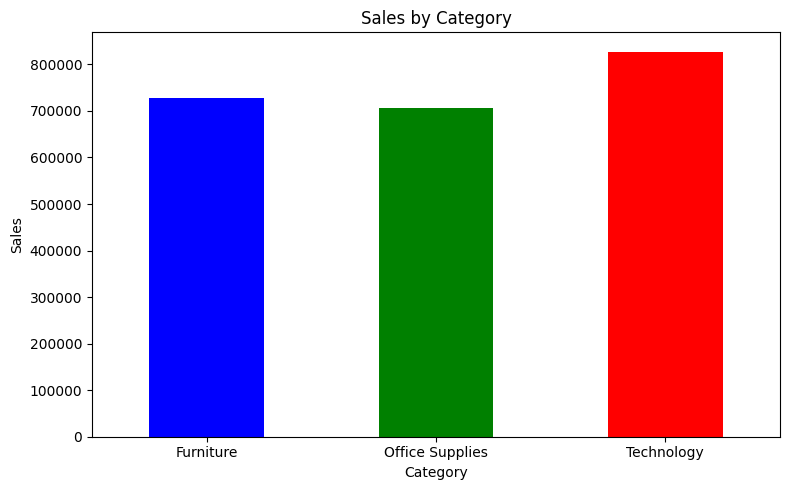

In [3]:
import matplotlib.pyplot as plt

# Chart 1 — Sales by Category
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().plot(kind='bar', color=['blue','green','red'])
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

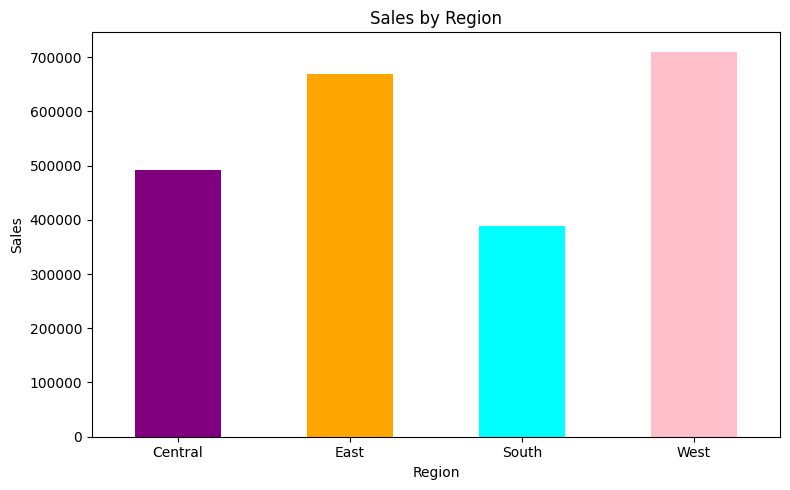

In [4]:
# Chart 2 — Sales by Region
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().plot(kind='bar', color=['purple','orange','cyan','pink'])
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

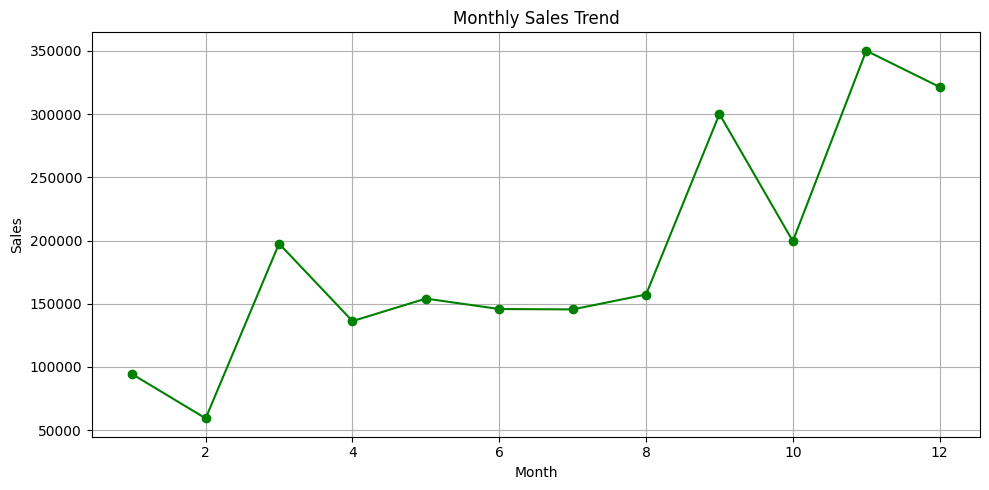

In [5]:
# Chart 3 — Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.month

plt.figure(figsize=(10,5))
df.groupby('Month')['Sales'].sum().plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# Save all charts as images
# Chart 1
df.groupby('Category')['Sales'].sum().plot(kind='bar', color=['blue','green','red'])
plt.title('Sales by Category')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.close()

# Chart 2
df.groupby('Region')['Sales'].sum().plot(kind='bar', color=['purple','orange','cyan','pink'])
plt.title('Sales by Region')
plt.tight_layout()
plt.savefig('region_sales.png')
plt.close()

# Chart 3
df.groupby('Month')['Sales'].sum().plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.close()

print("All charts saved! ✅")

All charts saved! ✅
